Using device: cpu


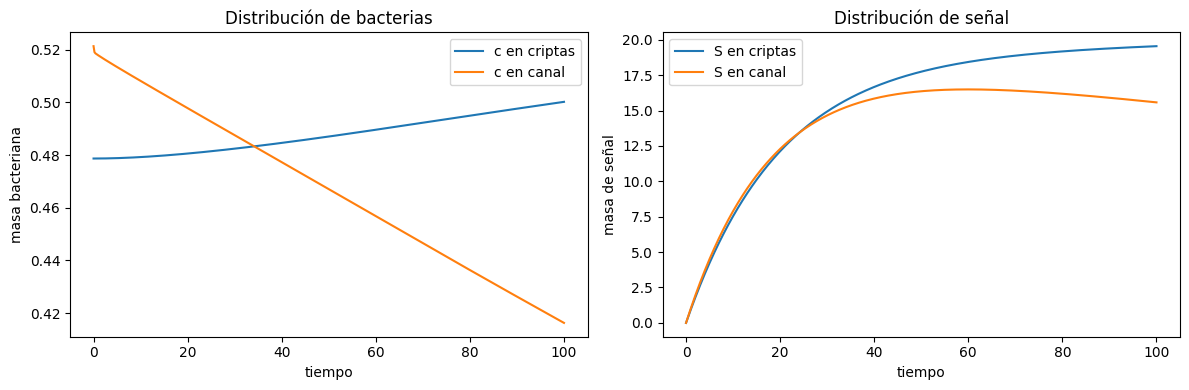

Video guardado como:
keller_segel_c_and_S.mp4


In [7]:
# ============================================================
# GPU / CPU SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from typing import Optional
import matplotlib as mpl
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
import matplotlib.animation as animation

FFMPEG_PATH: Optional[str] = r"C:/ffmpeg/bin/ffmpeg.exe"

if FFMPEG_PATH is not None and os.path.exists(FFMPEG_PATH):
    mpl.rcParams["animation.ffmpeg_path"] = FFMPEG_PATH

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    import cupy as xp
else:
    xp = np

print("Using device:", device)

# ============================================================
# GEOMETRÍA
# ============================================================

Nx, Ny = 220, 90

dx = 1.0
dy = 1.0

x_cpu = np.arange(Nx)
y_cpu = np.arange(Ny)

X_cpu, Y_cpu = np.meshgrid(x_cpu, y_cpu)

X = xp.asarray(X_cpu)
Y = xp.asarray(Y_cpu)

channel_h = 18

crypt_w = 18
crypt_depths = [18, 28, 40, 52, 64]
crypt_gap = 18

x0 = 35

solid_cpu = np.ones((Ny, Nx), dtype=bool)
solid_cpu[:channel_h, :] = False

crypt_slices = []

for i, d in enumerate(crypt_depths):

    xs = x0 + i * (crypt_w + crypt_gap)
    xe = xs + crypt_w

    ys = channel_h
    ye = channel_h + d

    solid_cpu[ys:ye, xs:xe] = False

    crypt_slices.append((ys, ye, xs, xe, d))

fluid_cpu = ~solid_cpu

solid = xp.asarray(solid_cpu)
fluid = xp.asarray(fluid_cpu)

# ============================================================
# MASKS
# ============================================================

channel_mask_cpu = np.zeros_like(fluid_cpu)
channel_mask_cpu[:channel_h, :] = fluid_cpu[:channel_h, :]

channel_mask = xp.asarray(channel_mask_cpu)

crypt_masks_cpu = []

for ys, ye, xs, xe, d in crypt_slices:

    m = np.zeros_like(fluid_cpu)
    m[ys:ye, xs:xe] = fluid_cpu[ys:ye, xs:xe]
    crypt_masks_cpu.append(m)

crypt_masks = [xp.asarray(m) for m in crypt_masks_cpu]

# ============================================================
# CONDICIÓN INICIAL DE BACTERIAS - PUNTO FUERTE EN EL CANAL
# ============================================================

# c0 = (
#     xp.exp(-((X - 15)**2) / (2 * 5**2))
#     *
#     xp.exp(-((Y - channel_h / 2)**2) / (2 * 5**2))
# )

# c0 *= fluid
# c0 /= c0.sum()

# ============================================================
# CONDICIÓN INICIAL DE BACTERIAS — HOMOGÉNEA
# ============================================================

c0 = xp.zeros((Ny, Nx), dtype=float)

c0[fluid] = 1.0

c0 /= c0.sum()

# ============================================================
# CONDICIÓN INICIAL DE SEÑAL
# ============================================================

S0 = xp.zeros_like(c0) 



# ============================================================
# VELOCIDAD DEL FLUIDO
# ============================================================

u_fluid = 1.0

Ufluid = xp.zeros_like(c0)
Vfluid = xp.zeros_like(c0)

Ufluid[channel_mask] = u_fluid

# ============================================================
# GPU -> CPU
# ============================================================

def to_cpu(a):

    if device == "cuda":
        return xp.asnumpy(a)

    return a

# ============================================================
# GRADIENTE
# ============================================================

def grad_field(A):

    dAy = xp.zeros_like(A)
    dAx = xp.zeros_like(A)

    dAy[1:-1, :] = (
        A[2:, :] - A[:-2, :]
    ) / (2 * dy)

    dAx[:, 1:-1] = (
        A[:, 2:] - A[:, :-2]
    ) / (2 * dx)

    dAy[solid] = 0
    dAx[solid] = 0

    return dAx, dAy

# ============================================================
# LAPLACIANO CON NO-FLUX EN PAREDES
# ============================================================

def laplacian_neumann_masked(A):

    Ap = A.copy()

    up = xp.roll(Ap, 1, axis=0)
    down = xp.roll(Ap, -1, axis=0)

    left = xp.roll(Ap, 1, axis=1)
    right = xp.roll(Ap, -1, axis=1)

    up[0, :] = Ap[0, :]
    down[-1, :] = Ap[-1, :]

    left[:, 0] = Ap[:, 0]
    right[:, -1] = Ap[:, -1]

    solid_up = xp.roll(solid, 1, axis=0)
    solid_down = xp.roll(solid, -1, axis=0)

    solid_left = xp.roll(solid, 1, axis=1)
    solid_right = xp.roll(solid, -1, axis=1)

    solid_up[0, :] = True
    solid_down[-1, :] = True

    solid_left[:, 0] = True
    solid_right[:, -1] = True

    up[solid_up] = Ap[solid_up]
    down[solid_down] = Ap[solid_down]

    left[solid_left] = Ap[solid_left]
    right[solid_right] = Ap[solid_right]

    L = (
        up + down + left + right - 4 * Ap
    ) / dx**2

    L[solid] = 0

    return L

# ============================================================
# ADVECCIÓN EN X
# ============================================================

def upwind_advection_x(A, U):

    F = U * A

    dFdx = xp.zeros_like(A)

    dFdx[:, 1:] = (
        F[:, 1:] - F[:, :-1]
    ) / dx

    dFdx[:, 0] = F[:, 0] / dx

    return -dFdx

# ============================================================
# DIVERGENCIA DE FLUJO
# ============================================================

def divergence_flux(Fx, Fy):

    div = xp.zeros_like(Fx)

    div[:, 1:-1] += (
        Fx[:, 2:] - Fx[:, :-2]
    ) / (2 * dx)

    div[1:-1, :] += (
        Fy[2:, :] - Fy[:-2, :]
    ) / (2 * dy)

    div[solid] = 0

    return -div

# ============================================================
# MÉTRICAS
# ============================================================

def compute_metrics(c, S, t):

    total_c = float(to_cpu(c.sum()))
    total_S = float(to_cpu(S.sum()))

    crypt_c = []
    crypt_S = []

    for m in crypt_masks:
        crypt_c.append(float(to_cpu(c[m].sum())))
        crypt_S.append(float(to_cpu(S[m].sum())))

    return {
        "time": t,
        "total_c": total_c,
        "total_S": total_S,
        "channel_c": float(to_cpu(c[channel_mask].sum())),
        "channel_S": float(to_cpu(S[channel_mask].sum())),
        "crypt_total_c": sum(crypt_c),
        "crypt_total_S": sum(crypt_S),
        **{f"crypt_{i+1}_c": crypt_c[i] for i in range(len(crypt_c))},
        **{f"crypt_{i+1}_S": crypt_S[i] for i in range(len(crypt_S))}
    }

# ============================================================
# SIMULACIÓN KELLER-SEGEL
# ============================================================

def simulate_keller_video(
    chi=0.1,
    alpha_b=0.1,
    alpha_S=1.0,
    D_c=100000,
    D_S=1000,
    beta=5.0,
    lamb=0.05,
    steps=1500,
    dt=0.02,
    frame_every=5,
    save_metrics_every=10,
    normalize_c=False
):

    c = c0.copy()
    S = S0.copy()

    Ub = alpha_b * Ufluid
    VSb = alpha_b * Vfluid

    US = alpha_S * Ufluid
    VS = alpha_S * Vfluid

    frames_c = []
    frames_S = []

    records = []

    for n in range(steps + 1):

        if n % frame_every == 0:
            frames_c.append(to_cpu(c.copy()))
            frames_S.append(to_cpu(S.copy()))

        if n % save_metrics_every == 0:
            records.append(compute_metrics(c, S, n * dt))

        # gradiente dinámico de S
        Sx, Sy = grad_field(S)

        # ----------------------------
        # Dinámica de bacterias c
        # ----------------------------
        dc = D_c * laplacian_neumann_masked(c)

        dc += upwind_advection_x(c, Ub)

        Fx_chem = chi * c * Sx
        Fy_chem = chi * c * Sy

        dc += divergence_flux(Fx_chem, Fy_chem)

        # ----------------------------
        # Dinámica de señal S
        # ----------------------------
        dSdt = D_S * laplacian_neumann_masked(S)

        dSdt += upwind_advection_x(S, US)

        dSdt += beta * c

        dSdt += -lamb * S

        # ----------------------------
        # Euler explícito
        # ----------------------------
        c = c + dt * dc
        S = S + dt * dSdt

        c[solid] = 0
        S[solid] = 0

        c[c < 0] = 0
        S[S < 0] = 0

        # salida abierta a la derecha
        c[:, -1] *= 0.80
        S[:, -1] *= 0.80

        if normalize_c:
            mass = c.sum()
            if mass > 0:
                c /= mass

    metrics = pd.DataFrame(records)

    return frames_c, frames_S, metrics

# ============================================================
# ANIMACIÓN c Y S
# ============================================================

def animate_c_and_S(
    frames_c,
    frames_S,
    title="Keller-Segel",
    interval=40,
    vmax_c=None,
    vmax_S=None
):

    if vmax_c is None:
        vmax_c = max(np.max(f) for f in frames_c)

    if vmax_S is None:
        vmax_S = max(np.max(f) for f in frames_S)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 4),
        sharex=True,
        sharey=True
    )

    img_c = axes[0].imshow(
        np.where(fluid_cpu, frames_c[0], np.nan),
        origin="upper",
        aspect="auto",
        cmap="inferno",
        vmin=0,
        vmax=vmax_c
    )

    img_S = axes[1].imshow(
        np.where(fluid_cpu, frames_S[0], np.nan),
        origin="upper",
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=vmax_S
    )

    axes[0].set_title("Bacterias c")
    axes[1].set_title("Señal S")

    for ax in axes:
        ax.set_xlabel("x")

    axes[0].set_ylabel("y")

    cb1 = plt.colorbar(img_c, ax=axes[0])
    cb1.set_label("c")

    cb2 = plt.colorbar(img_S, ax=axes[1])
    cb2.set_label("S")

    fig.suptitle(title)

    def update(i):

        img_c.set_array(
            np.where(fluid_cpu, frames_c[i], np.nan)
        )

        img_S.set_array(
            np.where(fluid_cpu, frames_S[i], np.nan)
        )

        fig.suptitle(f"{title} | frame {i}")

        return [img_c, img_S]

    anim = FuncAnimation(
        fig,
        update,
        frames=min(len(frames_c), len(frames_S)),
        interval=interval,
        blit=True
    )

    plt.close(fig)

    return anim

# ============================================================
# EJECUTAR SIMULACIÓN
# ============================================================

frames_c, frames_S, metrics = simulate_keller_video(
    chi=3.0,
    alpha_b=0.45,
    alpha_S=1.0,
    D_c=0.08,
    D_S=0.6,
    beta=2.0,
    lamb=0.05,
    steps=5000,
    dt=0.02,
    frame_every=15,
    save_metrics_every=10,
    normalize_c=False
)

metrics.head()

# ============================================================
# VER VIDEO EN NOTEBOOK
# ============================================================

anim = animate_c_and_S(
    frames_c,
    frames_S,
    title="Keller-Segel con advección de S en canal",
    interval=40
)

# HTML(anim.to_jshtml())

# ============================================================
# PLOTS DE MÉTRICAS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(metrics["time"], metrics["crypt_total_c"], label="c en criptas")
axes[0].plot(metrics["time"], metrics["channel_c"], label="c en canal")
axes[0].set_xlabel("tiempo")
axes[0].set_ylabel("masa bacteriana")
axes[0].legend()
axes[0].set_title("Distribución de bacterias")

axes[1].plot(metrics["time"], metrics["crypt_total_S"], label="S en criptas")
axes[1].plot(metrics["time"], metrics["channel_S"], label="S en canal")
axes[1].set_xlabel("tiempo")
axes[1].set_ylabel("masa de señal")
axes[1].legend()
axes[1].set_title("Distribución de señal")

plt.tight_layout()
plt.show()

# ============================================================
# GUARDAR MP4
# ============================================================

writer = FFMpegWriter(
    fps=25,
    metadata=dict(artist="Julia"),
    bitrate=1800
)

anim.save(
    "keller_segel_c_and_S.mp4",
    writer=writer
)

print("Video guardado como:")
print("keller_segel_c_and_S.mp4")